## Latitude bands recycling
- running with merged data (zero evap over ocean) over three different band options
- running with rotation options and plotting seasonal averages for all rotations

In [5]:
import numpy as np
import xarray as xr
import pandas as pd
import scipy
import sys 
import warnings
warnings.filterwarnings('ignore')
import geopandas as gpd
from shapely.geometry import mapping
import cartopy.crs as ccrs
import cartopy.feature
import matplotlib.pyplot as plt
import matplotlib as mpl
import time as timer
start_all = timer.time()

### Read in surface and pressure level files (current ERA5 conventions)
**Surface file options:**
- S_SE (surface vars including only surface evaporation)
- S_LSE (surface vars including land and surface evaporation)

**Pressure level file options:**
- L_M (pressure level vars resampled to monthly timestep)
- L_HI (pressure level vars with integrated moist flux calcualted hourly and then resampled to monthly timestep)

#### **Read in pre-processed files that have the following conversions:**

### **Units must be as linked here:**
https://github.com/Assimila/f4r-bulk-recycling-model

- evaporation and precip in mm/day
- flux in m/s
- pressure in hPa
- humidity in g/kg


---------------------------------

**Read in ERA5 data on pressure levels**
- resampled to monthly MS timestep
- shum multiplied by 1000 to convert from kg/kg --> g/kg
- pressure levels are divided by 100 to convert from Pa to hPa (only for fortnightly files)
- sort data by descending pressure levels (only for fortnightly files)


**Input file units:**
- plev - pa
- q - kg/kg
- u - m/s
- v - m/s

** ***Might include Fx and Fy if L_HI is being read in***

**Read in ERA5 land and surface data**
- Land: selecting hour 23 (0-23) of Prec and Evap because of how ERA5 Land variables are accumulated (https://confluence.ecmwf.int/pages/viewpage.action?pageId=197702790 - https://confluence.ecmwf.int/display/CKB/ERA5-Land%3A+data+documentation#ERA5Land:datadocumentation-accumulationsAccumulations)
- Surface: evap is accumulated per hour so a daily sum is calculated
- prec is multiplied by 1000 to convert from m to mm
- evap is multiplied by -1000 to convert from m to mm and upward fluxes in land model are considered negative
- Prec, Evap, and Psfc are then resampled to MS monthly and also interpolated to coarser pressure level grid

**Input file units:**
- tp - m (no longer reading in)
- e - m (-)
- sp - pa

**Merging all input datasets into one dataset for recyling code called ds**
- close both input datasets
- sort everything so latitude is south to north
- transpose dimensions so they run (lon,lat,level,time) as in recycling code
- save input ds to file

**Integrate zonal and meridional moisture flux**
- **Must check if there are any nans in input arrays** - there can be none because we are using nans as an indicator in the modified definitions

In [6]:
dataf ="/Volumes/New_5TB/ESA_F4R/2026_mergeds/" 
datao ="/Volumes/New_5TB/ESA_F4R/2026_rho/bands/" 
datap ="/Volumes/New_5TB/ESA_F4R/2026_plots/bands/" 
datam ="/Volumes/New_5TB/ESA_F4R/ERA5_monthly/" 

datas ="/Users/ellendyer/Library/Mobile Documents/com~apple~CloudDocs/1SHARED_WORK/Work/3_ESA_GRANT/MODEL/Shapefiles/"
shp_cod = gpd.read_file(datas+"congo_basin_evergreen.shp")

#show disgnostic plots during recycling calcs?
plots = 'NO'

#select convention for input files
S_NAME = "S_SE" # S_SE or S_LSE 
L_NAME = "L_HI" # L_M or L_HI

#regrid all data to the following resolution (both lat and lon)
grid = 0.5

#thresholds for recycling calculations
max_iter = 1000    #ceiling of iterations tried
tol = 1e-3         #tolerance for convergence

#tune these nudging values as needed
offset = 2.0        #evaporation offset to add to points that don't converg
kernel_size = 15    #neighbouring grids over which to balance the evaporation offset

#thresholds for what an unstable point is and how many are premitted
p = 4           #max number of very unstable points
s_p = 4         #number of less stable points
thresh=1.75     #extreme threshold
s_thresh = 1.75 #less extreme threshold

### Band definitions used if reducing region into latitudinal bands
- North: 5-12**N** / 10-31**E**
- Equatorial: 5**S**-5**N** / 8-29**E**
- South: 15-5**S** / 12-31**E**

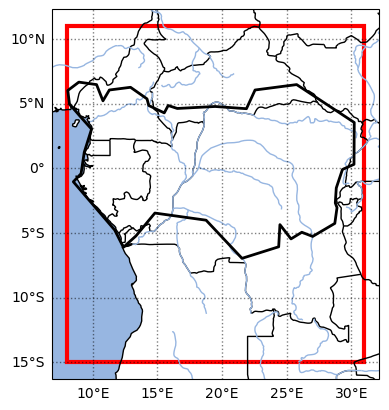

<Figure size 640x480 with 0 Axes>

In [7]:
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS)
ax.add_feature(cartopy.feature.RIVERS)
ax.add_feature(cartopy.feature.OCEAN)
ax.add_patch(plt.Rectangle((8, -15), 23, 26, ls="-", lw=3, ec="r", fc="none"))
shp_cod.plot(ax=ax, edgecolor='black',facecolor='none',lw=2,zorder=2,linestyle='-')
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='black', alpha=0.5, linestyle='dotted')
gl.top_labels = False
gl.right_labels = False
plt.show()
plt.clf()

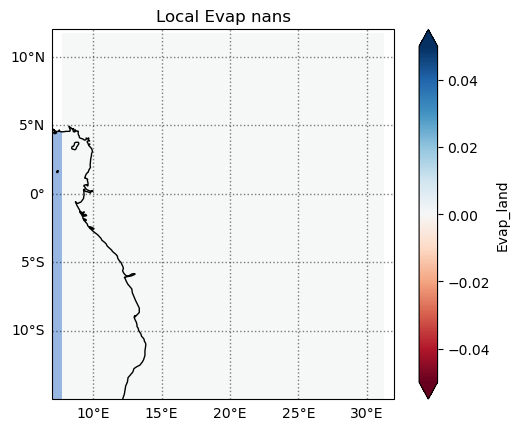

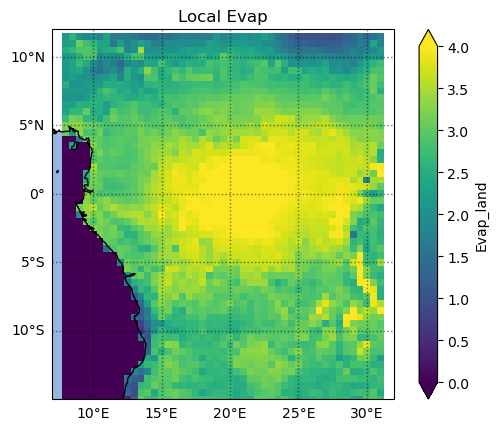

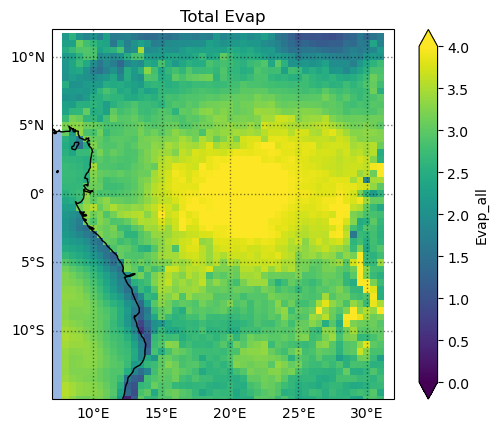

False
30456


<Figure size 640x480 with 0 Axes>

In [8]:
dsS = xr.open_dataset(dataf+"merge_era_surface.nc")
dsL = xr.open_mfdataset(dataf+"merge_erads_"+L_NAME+"_*.nc")
ds = xr.merge([dsS,dsL])

#slice timeseries for calculation
ds = ds.sel(time=slice('1990-01-01','1990-12-31'))

#regrid input variables if necessary
ds = ds.interp(lat=np.arange(ds.coords["lat"].min().values,ds.coords["lat"].max().values,grid), lon=np.arange(ds.coords["lon"].min().values,ds.coords["lon"].max().values,grid), method="linear")

#Clip out specific band
ds = ds.transpose("time","level","lat","lon",missing_dims='ignore')
ds = ds.sel(lon=slice(8,31),lat=slice(-15,12),drop=True)

Evap_land_nan = ds['Evap_land'].where(ds['Evap_land'].isnull(),0.0)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cartopy.feature.OCEAN)
Evap_land_nan.mean('time').plot(ax=ax,transform=ccrs.PlateCarree(),
                                       add_colorbar=True,
                                       #vmin=0,vmax=2,
                                       alpha=1,
                                       cmap=plt.cm.RdBu,
                                       extend="both")

ax.set_extent([7, 32, -15, 12])
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='black', alpha=0.5, linestyle='dotted')
gl.top_labels = False
gl.right_labels = False
ax.set_title('Local Evap nans')
#plt.savefig('Local Evap nans')
plt.show()
plt.clf()


ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cartopy.feature.OCEAN)
ds['Evap_land'].mean('time').plot(ax=ax,transform=ccrs.PlateCarree(),
                                       add_colorbar=True,
                                       vmin=0,vmax=4,
                                       alpha=1,
                                       cmap=plt.cm.viridis,
                                       extend="both")

ax.set_extent([7, 32, -15, 12])
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='black', alpha=0.5, linestyle='dotted')
gl.top_labels = False
gl.right_labels = False
ax.set_title('Local Evap')
#plt.savefig()
plt.show()
plt.clf()

ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cartopy.feature.OCEAN)
ds['Evap_all'].mean('time').plot(ax=ax,transform=ccrs.PlateCarree(),
                                       add_colorbar=True,
                                       vmin=0,vmax=4,
                                       alpha=1,
                                       cmap=plt.cm.viridis,
                                       extend="both")

ax.set_extent([7, 32, -15, 12])
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='black', alpha=0.5, linestyle='dotted')
gl.top_labels = False
gl.right_labels = False
ax.set_title('Total Evap')
#plt.savefig()
plt.show()
plt.clf()
          
ds = ds.transpose("lon","lat","level","time",missing_dims='ignore')
print(np.isnan(ds['Evap_land'].values).any())
print(ds['Evap_land'].isnull().count().values)


mask = xr.open_dataset("/Users/ellendyer/Documents/GitHub/f4r-bulk-recycling-model/lsm_1279l4_0.1x0.1.grb_v4_unpack.nc")['lsm']
mask = mask.rename({'latitude':'lat','longitude':'lon'})
mask = mask.squeeze(['time'], drop=True)
mask = mask.where(mask.lon<24.0,1)

In [9]:
if L_NAME=='L_HI':
    Fx = ds['Fx']
    Fy = ds['Fy']
    
else:
    #Prepping datasets near surface for recycling
    import bulk_recycling_model.numerical_integration
    
    # Integrate 10^-3 Shum Uwnd dp
    # Because the integration limits are from high pressure to low pressure, we need to invert the sign.
    integrand = -1 * 1e-3 * ds["Shum"] * ds["Uwnd"]
    Fx = bulk_recycling_model.numerical_integration.integrate_with_extrapolation(integrand, ds["Psfc"])
    # Units: mb x m/s
    
    # Integrate 10^-3 Shum Vwnd dp
    # Because the integration limits are from high pressure to low pressure, we need to invert the sign.
    integrand = -1 * 1e-3 * ds["Shum"] * ds["Vwnd"]
    Fy = bulk_recycling_model.numerical_integration.integrate_with_extrapolation(integrand, ds["Psfc"])
    # Units: mb x m/s

**Prepare scaled data for recycling code**
- Evaporation and moisture fluxes


In [10]:
# Prepare and scale the data
from bulk_recycling_model import preprocess
from bulk_recycling_model.axis import Axis
from bulk_recycling_model.scaling import Scaling, UnitSystem

# degrees
L = ds.coords["lon"].max().item() - ds.coords["lon"].min().item()
# convert to meters
L = L * 111e3 * np.cos(np.deg2rad(ds.coords["lat"].mean().item()))
dx = L / ds.sizes["lon"]

# lon axis
lon_axis = Axis(
    ds.coords["lon"].min().item(),
    ds.coords["lon"].diff("lon").mean().item(),
    ds.sizes["lon"],
)

# degrees
H = ds.coords["lat"].values[-1] - ds.coords["lat"].values[0]
# convert to meters
H = H * 111e3
dy = H / ds.sizes["lat"]

# lat axis
lat_axis = Axis(
    ds.coords["lat"].min().item(),
    ds.coords["lat"].diff("lat").mean().item(),
    ds.sizes["lat"],
)

print(f"{L = :.2e} m")
print(f"{dx = :.2e} m")
print(f"{H = :.2e} m")
print(f"{dy = :.2e} m")

# make a scaling object to convert between unit systems
scaling = Scaling(H)

dx = scaling.distance.convert(dx, UnitSystem.SI, UnitSystem.scaled)
dy = scaling.distance.convert(dy, UnitSystem.SI, UnitSystem.scaled)
print(f"{dx = :.2e} scaled")
print(f"{dy = :.2e} scaled")

# convert Fx and Fy to scaled units
Fx_clim = Fx.groupby('time.month').mean('time') 
Fy_clim = Fy.groupby('time.month').mean('time') 
Fx_plot = scaling.water_vapor_flux.convert(Fx_clim.values, UnitSystem.natural, UnitSystem.scaled)
Fy_plot = scaling.water_vapor_flux.convert(Fy_clim.values, UnitSystem.natural, UnitSystem.scaled)

Fx = scaling.water_vapor_flux.convert(Fx.values, UnitSystem.natural, UnitSystem.scaled)
Fy = scaling.water_vapor_flux.convert(Fy.values, UnitSystem.natural, UnitSystem.scaled)

# convert E to scaled units
# Do this for both the total E and the local regionally clipped E]
E_total = scaling.evaporation.convert(ds["Evap_all"].values, UnitSystem.natural, UnitSystem.scaled)
E_local = scaling.evaporation.convert(ds["Evap_land"].values, UnitSystem.natural, UnitSystem.scaled)

e_all_clim = ds["Evap_all"].groupby('time.month').mean('time') 
e_land_clim = ds["Evap_land"].groupby('time.month').mean('time') 
E_total_plot = scaling.evaporation.convert(e_all_clim.values, UnitSystem.natural, UnitSystem.scaled)
E_local_plot = scaling.evaporation.convert(e_land_clim.values, UnitSystem.natural, UnitSystem.scaled)

L = 2.55e+06 m
dx = 5.43e+04 m
H = 2.94e+06 m
dy = 5.45e+04 m
dx = 1.85e-02 scaled
dy = 1.85e-02 scaled


**Plot the scaled E array**


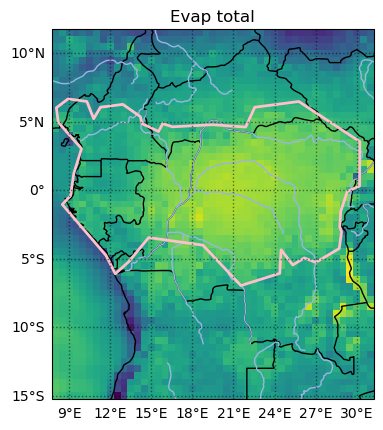

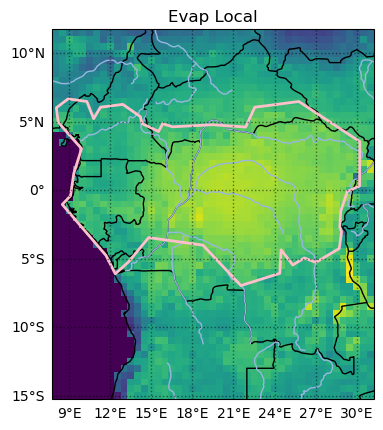

<Figure size 640x480 with 0 Axes>

In [11]:
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS)
ax.add_feature(cartopy.feature.RIVERS)
ax.add_feature(cartopy.feature.OCEAN)
#Overlay with all ward outline
shp_cod.plot(ax=ax, edgecolor='pink',facecolor='none',lw=2,zorder=2,linestyle='-')
#Plot data
Ea = np.transpose(np.average(E_total,axis=2))
collection = plt.pcolormesh(ds.lon, ds.lat,Ea)
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='black', alpha=0.5, linestyle='dotted')
gl.top_labels = False
gl.right_labels = False
ax.set_title("Evap total")
#plt.savefig()
plt.show()
plt.clf()

ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS)
ax.add_feature(cartopy.feature.RIVERS)
ax.add_feature(cartopy.feature.OCEAN)
#Overlay with all ward outline
shp_cod.plot(ax=ax, edgecolor='pink',facecolor='none',lw=2,zorder=2,linestyle='-')
#Plot data
Ea = np.transpose(np.average(E_local,axis=2))
collection = plt.pcolormesh(ds.lon, ds.lat,Ea)
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='black', alpha=0.5, linestyle='dotted')
gl.top_labels = False
gl.right_labels = False
ax.set_title('Evap Local')
#plt.savefig()
plt.show()
plt.clf()


### Plot precipitation calculated as per model and calculated by reanalysis

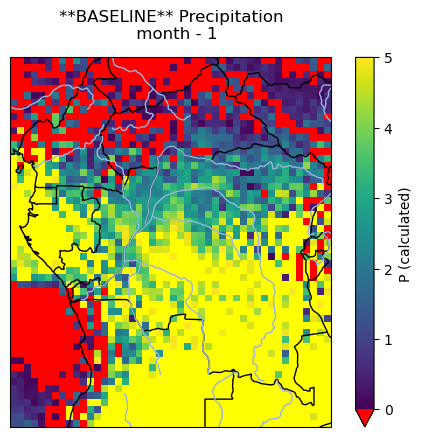

<Figure size 640x480 with 0 Axes>

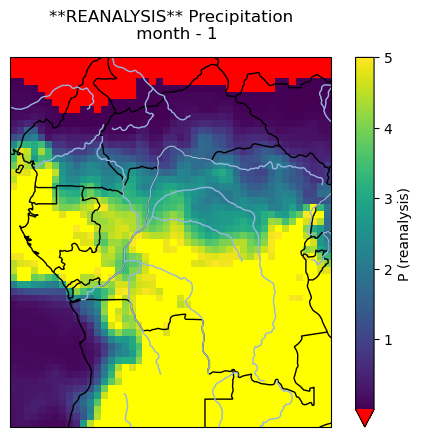

<Figure size 640x480 with 0 Axes>

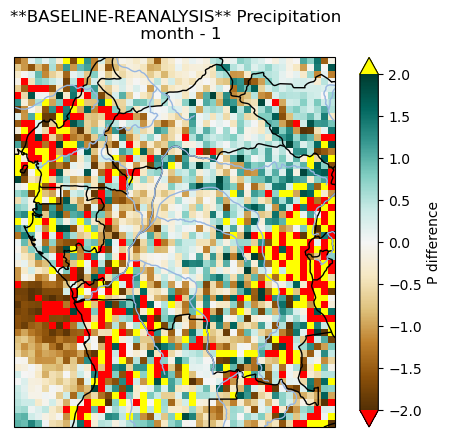

<Figure size 640x480 with 0 Axes>

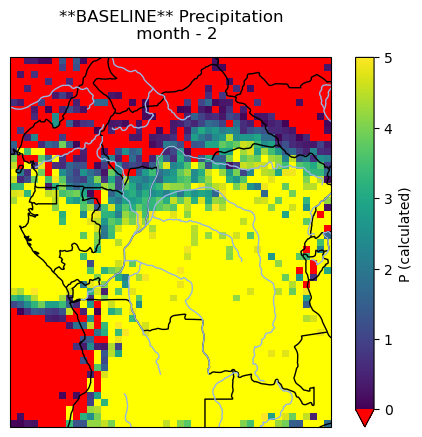

<Figure size 640x480 with 0 Axes>

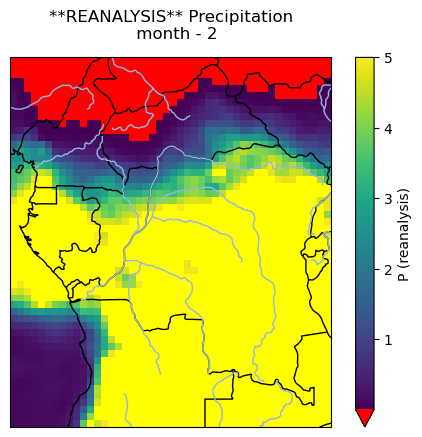

<Figure size 640x480 with 0 Axes>

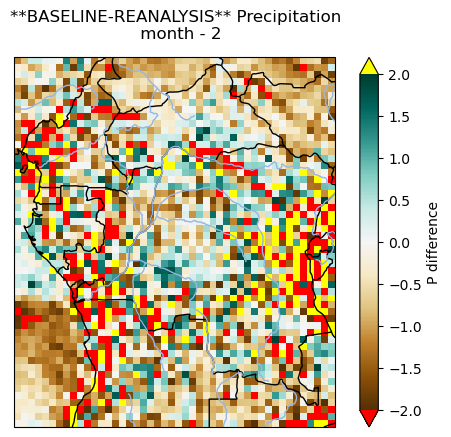

<Figure size 640x480 with 0 Axes>

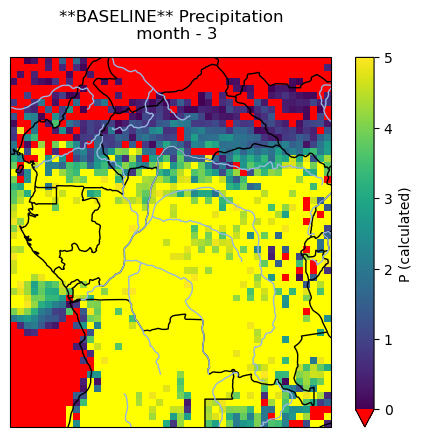

<Figure size 640x480 with 0 Axes>

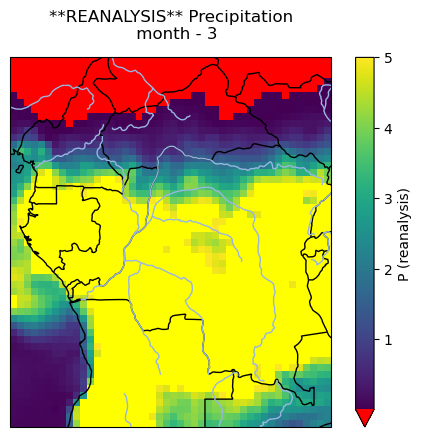

<Figure size 640x480 with 0 Axes>

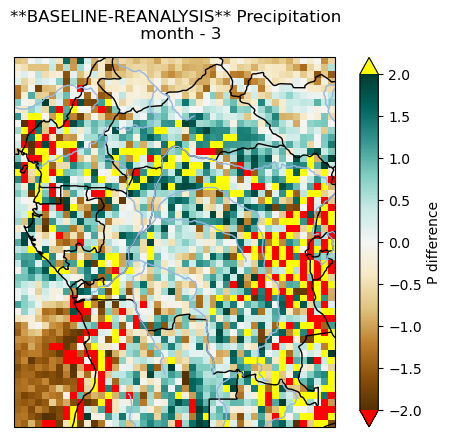

<Figure size 640x480 with 0 Axes>

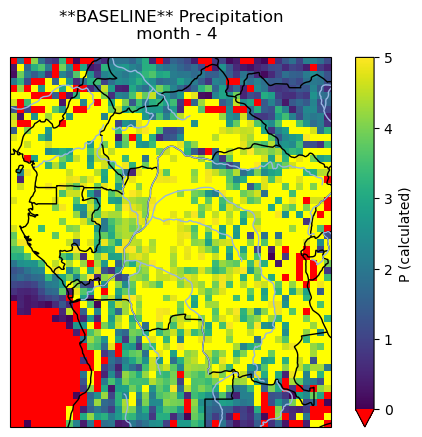

<Figure size 640x480 with 0 Axes>

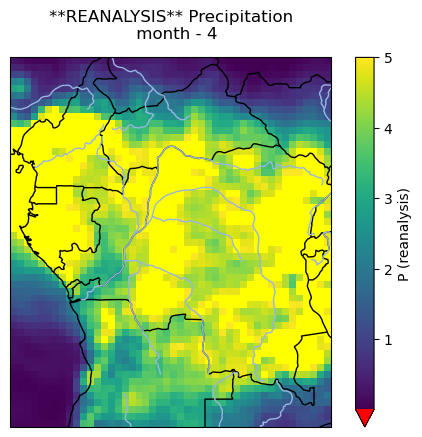

<Figure size 640x480 with 0 Axes>

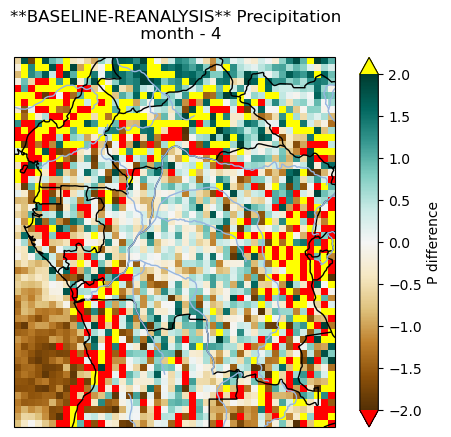

<Figure size 640x480 with 0 Axes>

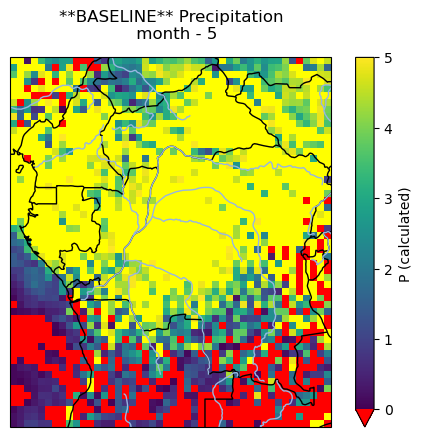

<Figure size 640x480 with 0 Axes>

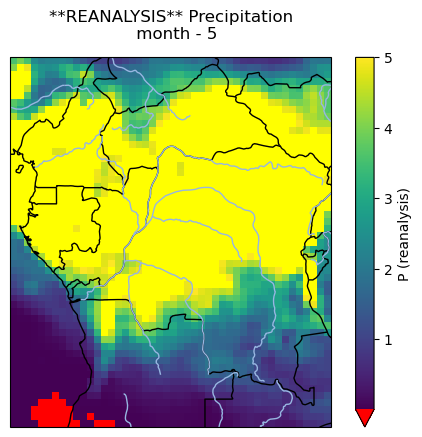

<Figure size 640x480 with 0 Axes>

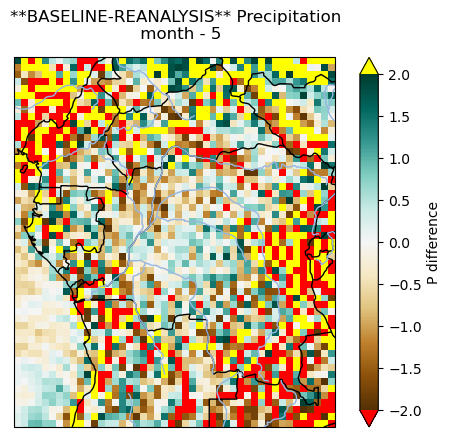

<Figure size 640x480 with 0 Axes>

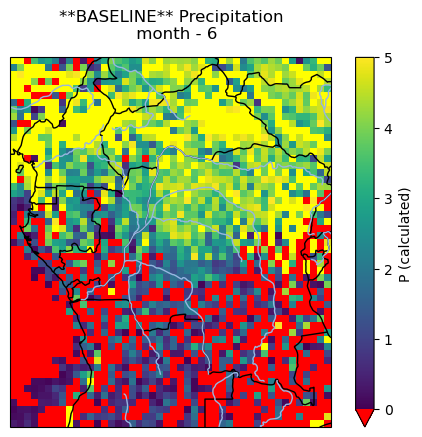

<Figure size 640x480 with 0 Axes>

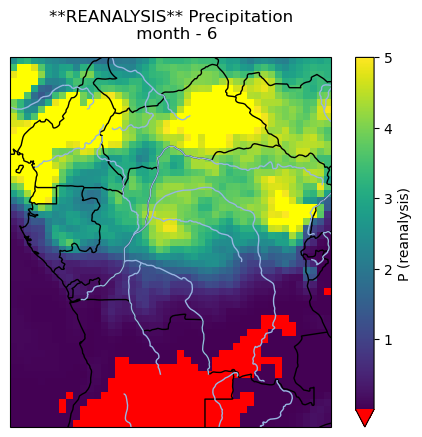

<Figure size 640x480 with 0 Axes>

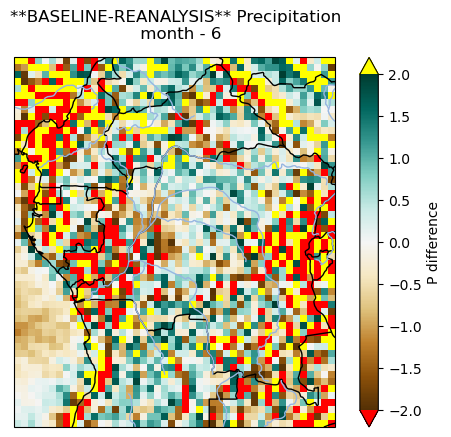

<Figure size 640x480 with 0 Axes>

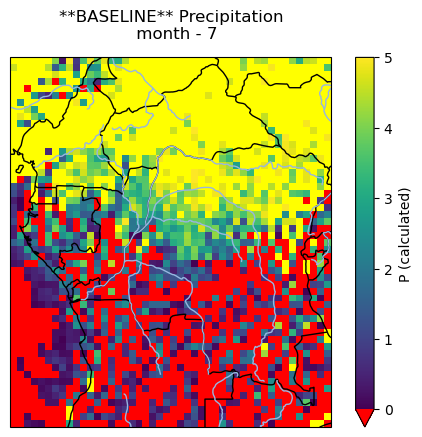

<Figure size 640x480 with 0 Axes>

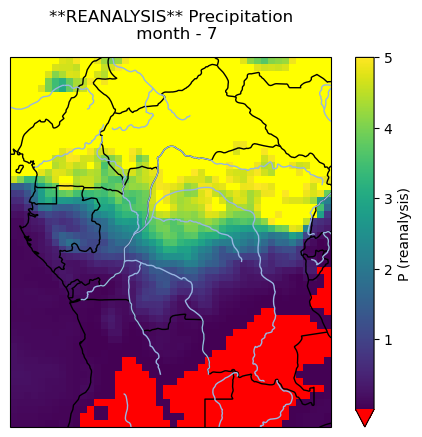

<Figure size 640x480 with 0 Axes>

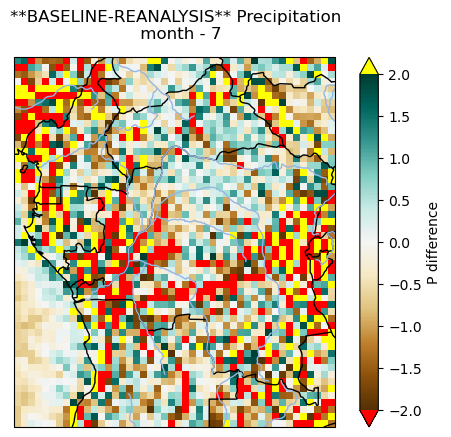

<Figure size 640x480 with 0 Axes>

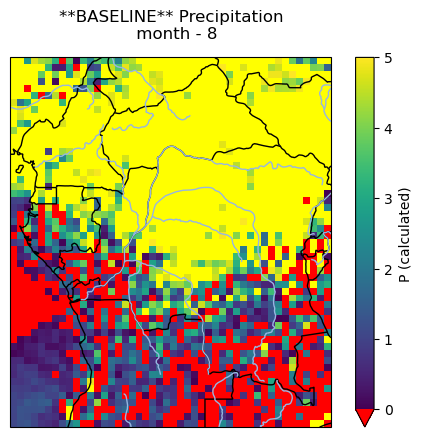

<Figure size 640x480 with 0 Axes>

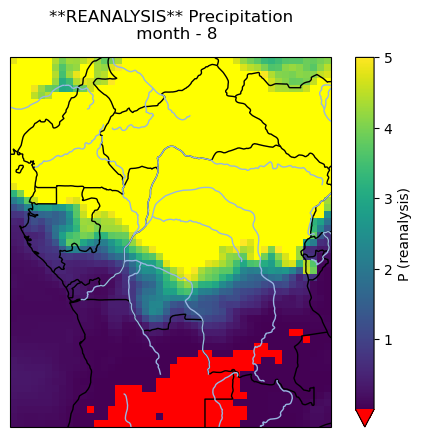

<Figure size 640x480 with 0 Axes>

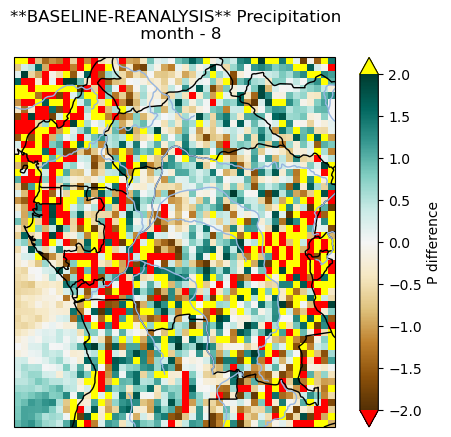

<Figure size 640x480 with 0 Axes>

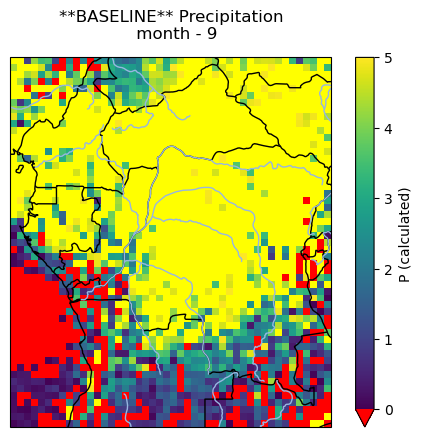

<Figure size 640x480 with 0 Axes>

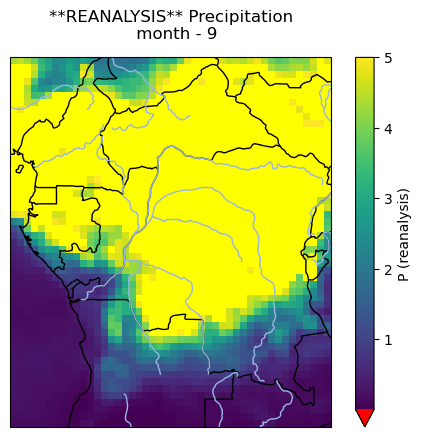

<Figure size 640x480 with 0 Axes>

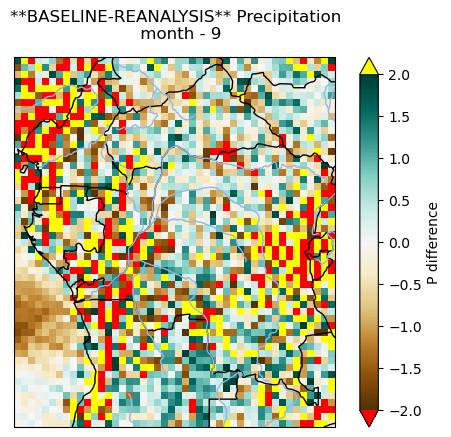

<Figure size 640x480 with 0 Axes>

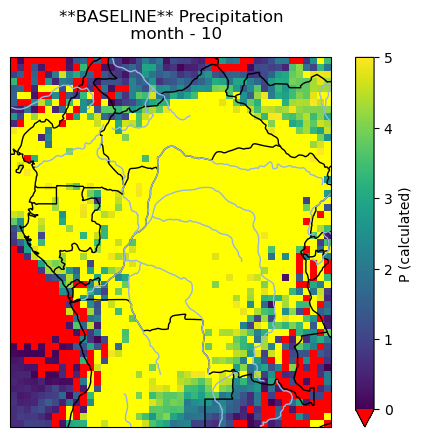

<Figure size 640x480 with 0 Axes>

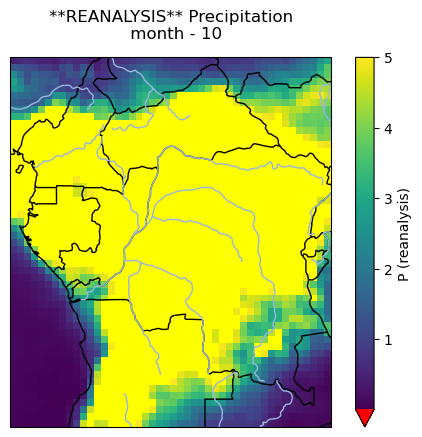

<Figure size 640x480 with 0 Axes>

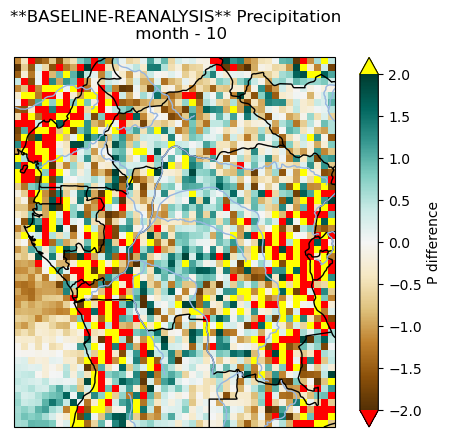

<Figure size 640x480 with 0 Axes>

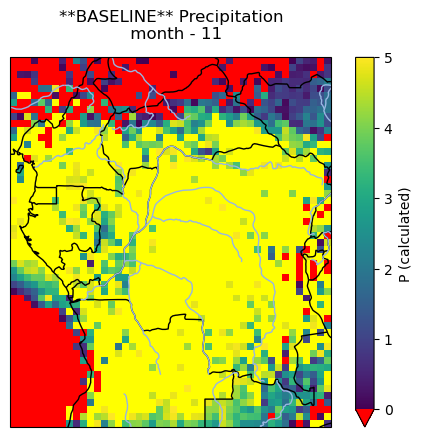

<Figure size 640x480 with 0 Axes>

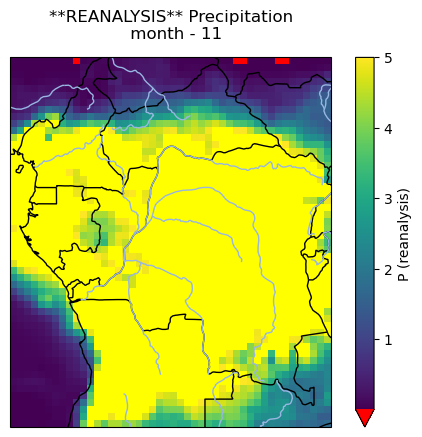

<Figure size 640x480 with 0 Axes>

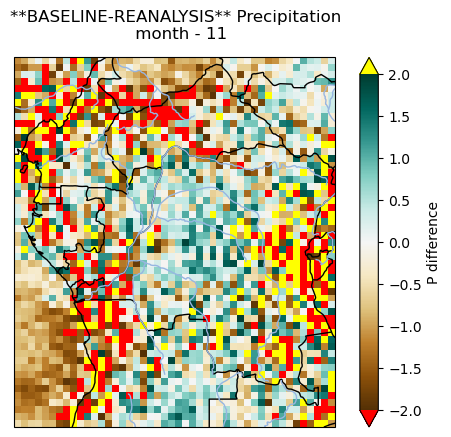

<Figure size 640x480 with 0 Axes>

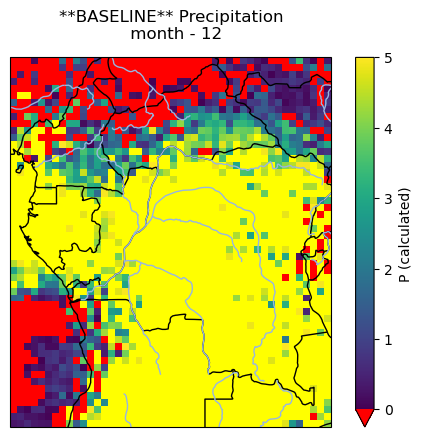

<Figure size 640x480 with 0 Axes>

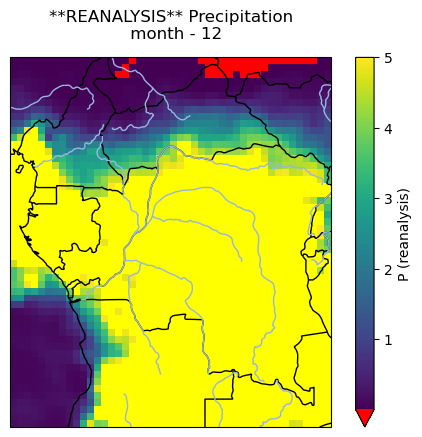

<Figure size 640x480 with 0 Axes>

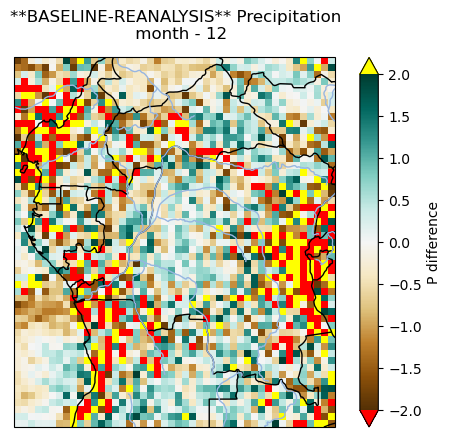

<Figure size 640x480 with 0 Axes>

In [12]:
era_prec = ds['Prec'].groupby('time.month').mean('time').values

for i in range(0,12):
     
    # preprocess E onto the secondary grid
    Ei_total_plot = preprocess.prepare_E(E_total_plot[:,:,i])
    Ei_local_plot = preprocess.prepare_E(E_local_plot[:,:,i])
    
    # preprocess water vapor fluxes onto the secondary grid
    Fxi_left_plot = preprocess.prepare_Fx_left(Fx_plot[:,:,i])
    Fxi_right_plot = preprocess.prepare_Fx_right(Fx_plot[:,:,i])
    Fyi_bottom_plot = preprocess.prepare_Fy_bottom(Fy_plot[:,:,i])
    Fyi_top_plot = preprocess.prepare_Fy_top(Fy_plot[:,:,i])
    
    # compute P
    Pi_plot = preprocess.calculate_precipitation(Fxi_left_plot, Fxi_right_plot, Fyi_bottom_plot, Fyi_top_plot, Ei_total_plot, dx, dy)
    PR_plot = np.transpose(preprocess.prepare_P(era_prec[:,:,i]))
    Pi_plot = np.transpose((Pi_plot))
    pdiff = Pi_plot-PR_plot
    
    lon_ar = np.linspace(start=ds.coords["lon"].min().values+lon_axis.step/2,
                            stop=ds.coords["lon"].max().values-lon_axis.step/2,
                            num=lon_axis.n_points-1)
    lat_ar = np.linspace(start=ds.coords["lat"].min().values+lat_axis.step/2,
                            stop=ds.coords["lat"].max().values-lat_axis.step/2,
                            num=lat_axis.n_points-1)
    
    # Create a precip plot
    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS)
    ax.add_feature(cartopy.feature.RIVERS)
    ax.add_feature(cartopy.feature.OCEAN)
    cmap=plt.cm.viridis
    cmap.set_extremes(over='yellow')
    cmap.set_extremes(under='red')
    
    collection = plt.pcolormesh(lon_ar, lat_ar, Pi_plot, 
                                     shading='auto',
                                     alpha=1,cmap=cmap, 
                                     vmin=0.0,vmax=5.0)
    fig.colorbar(collection, label="P (calculated)",extend='min')
    fig.suptitle("**BASELINE** Precipitation \n month - "+str(i+1))
    plt.show()
    plt.clf()
    
    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS)
    ax.add_feature(cartopy.feature.RIVERS)
    ax.add_feature(cartopy.feature.OCEAN)
    cmap=plt.cm.viridis
    cmap.set_extremes(over='yellow')
    cmap.set_extremes(under='red')
    
    collection = plt.pcolormesh(lon_ar, lat_ar, PR_plot, 
                                     alpha=1,cmap=cmap,
                                     vmin=0.001,vmax=5.0)
    fig.colorbar(collection, label="P (reanalysis)",extend='min')
    fig.suptitle("**REANALYSIS** Precipitation \n month - "+str(i+1))
    plt.show()
    plt.clf()
    
    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS)
    ax.add_feature(cartopy.feature.RIVERS)
    ax.add_feature(cartopy.feature.OCEAN)
    cmap=plt.cm.BrBG
    cmap.set_extremes(over='yellow')
    cmap.set_extremes(under='red')
    
    collection = plt.pcolormesh(lon_ar, lat_ar, pdiff, 
                                     alpha=1,cmap=cmap,
                                     vmin=-2.0,vmax=2.0)
    fig.colorbar(collection, label="P difference",extend='both')
    fig.suptitle("**BASELINE-REANALYSIS** Precipitation \n month - "+str(i+1))
    plt.show()
    plt.clf()

**Run recycling model for each timestep**
- Create recycling output array based on the shape of one of the surface input files: evap 
- Translate evap and fluxes to secondary grid
- Calculate modeled precipitation
- Plot scaled input variables (evap and fluxes)
- Run through each timestep in the input files and calculate recycling ratio at each timestep across domain
- Plot rho and convergence metric for each timestep

In [13]:
import matplotlib.pyplot as plt
import logging
logging.basicConfig()
#logging.getLogger("bulk_recycling_model").setLevel(logging.INFO)
logging.getLogger("bulk_recycling_model").setLevel(logging.ERROR)
from bulk_recycling_model import plotting
from bulk_recycling_model.main import run_4_orientations, run_rotated
from bulk_recycling_model import coefficients

#Make the rho array the same shape as the total E - will clip the external points at the end
rho_ar = np.empty((4,np.shape(E_total)[0]-1,np.shape(E_total)[1]-1,np.shape(E_total)[2]))
Pi_ar = np.empty((np.shape(E_total)[0]-1,np.shape(E_total)[1]-1,np.shape(E_total)[2]))
#Entering preprocessing and time step loop
#Run model and plot
count_success_pre_nudge = 0
count_success_post_nudge = 0
count_fail_pre_nudge = 0
count_fail_post_nudge = 0
too_many_pixels = 0
no_hot_pixel = 0
for i,time in enumerate(ds.time):
     
    # preprocess E onto the secondary grid
    Ei_total = preprocess.prepare_E(E_total[:,:,i])
    Ei_local = preprocess.prepare_E(E_local[:,:,i])
    
    # preprocess water vapor fluxes onto the secondary grid
    Fxi_left = preprocess.prepare_Fx_left(Fx[:,:,i])
    Fxi_right = preprocess.prepare_Fx_right(Fx[:,:,i])
    Fyi_bottom = preprocess.prepare_Fy_bottom(Fy[:,:,i])
    Fyi_top = preprocess.prepare_Fy_top(Fy[:,:,i])
    
    # compute P
    Pi = preprocess.calculate_precipitation(Fxi_left, Fxi_right, Fyi_bottom, Fyi_top, Ei_total, dx, dy)
    Pi_ar[:,:,i]=Pi
    
    # Run the model
    status = run_4_orientations(
        Fxi_left,
        Fxi_right,
        Fyi_bottom,
        Fyi_top,
        Ei_local,
        Pi,
        dx,
        dy,
        R=0.2,
        R_1=0.2,
        max_iter=max_iter,
        tol=tol,
    )
    #Print timestep and status (converged or not) and add rho to recycling ration array
    print(i,time.values)
    for ROT in np.arange(0,4):
        #print(ROT,status[ROT]['success'],'**pre-nudge')    
        if status[ROT]['success']==True:
            rho_ar[ROT,:,:,i] = status[ROT]["rho"]
            count_success_pre_nudge = count_success_pre_nudge + 1
        else:
            rho_ar[ROT,:,:,i] = np.nan
            count_fail_pre_nudge = count_fail_pre_nudge + 1
            
            #----Pre-nudge------------------------
            
            coeffs = coefficients.Coefficients(Fxi_left, Fxi_right, Fyi_bottom, Fyi_top, Ei_local, Pi, dx,dy)
            instability_heuristic = coeffs.rotated_instability_heuristic(k=ROT)

            if plots=='YES': 
                # plot the convergence
                deltas = status[ROT]["deltas"]
                fig, ax = plt.subplots()
                ax.plot(deltas)
                ax.set_title("Rot: "+str(ROT)+" - Convergence")
                ax.set_xlabel("Iteration")
                plt.show()
                plt.close()
            
            #identify hot pixel
            from bulk_recycling_model.numerical_stability_ED import identify_hot_pixel, identify_hot_pixel_thresh, nudge_hot_pixel
            #printing example of the hottest pixels
            #hot_ind = identify_hot_pixel(p,coeffs.rotated_instability_heuristic(k=ROT))
            hot_ind = identify_hot_pixel_thresh(thresh,coeffs.rotated_instability_heuristic(k=ROT))
            if len(hot_ind)>p:
                hot_ind=hot_ind
            if len(hot_ind)==0:
                hot_ind = identify_hot_pixel_thresh(s_thresh,coeffs.rotated_instability_heuristic(k=ROT)) 
                if len(hot_ind)>0:
                    hot_ind = identify_hot_pixel(s_p,coeffs.rotated_instability_heuristic(k=ROT)) 
            print('*There are ',len(hot_ind),' hot pixels*')
            if len(hot_ind)>0 and len(hot_ind)<=p:
                i_hot, j_hot = np.unravel_index(np.argmax(instability_heuristic, axis=None), instability_heuristic.shape)
                #print(
                #    f"Hottest pixel identified at (i={i_hot}, j={j_hot}) "
                #    f"with instability heuristic = {coeffs.rotated_instability_heuristic(k=ROT)[i_hot, j_hot]}"
                #)
                #print("E =", Ei_local[i_hot, j_hot])
                #print("P =", Pi[i_hot, j_hot])
                
                if plots=='YES':
                    # Create a evap plot
                    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
                    ax.coastlines()
                    ax.add_feature(cartopy.feature.BORDERS)
                    ax.add_feature(cartopy.feature.RIVERS)
                    ax.add_feature(cartopy.feature.OCEAN)
                    cmap=plt.cm.viridis
                    cmap.set_extremes(over='orange')
                    cmap.set_extremes(under='pink')
                    collection = plotting.pcolormesh(ax, Ei_local, lon_axis, lat_axis, 
                                                     alpha=1,cmap=cmap,
                                                     vmin=0.0,vmax=5.0)
                    plt.scatter(ds.coords["lon"][i_hot],ds.coords["lat"][j_hot],s=100,c=Ei_local[i_hot,j_hot],
                                edgecolors='white',cmap=cmap, vmin=0.0,vmax=5.0)
                    fig.colorbar(collection,extend='both',location='bottom')
                    fig.suptitle("E Local - pre-nudge")
                    plt.show()
                    plt.clf()
                    
                    #Flux subplot
                    vmin = -10
                    vmax = 10
                    fig, axs = plt.subplots(2, 2)#, subplot_kw={'projection': ccrs.PlateCarree()})
                    cmap=plt.cm.viridis
                    cmap.set_extremes(over='orange')
                    cmap.set_extremes(under='pink')
                    p1 = plotting.pcolormesh(axs[0,0],Fxi_left, lon_axis, lat_axis, 
                                                     alpha=1,cmap=cmap,
                                                     vmin=vmin,vmax=vmax)
                    axs[0,0].set_title('Fxi_left')
                    axs[0,0].scatter(ds.coords["lon"][i_hot],ds.coords["lat"][j_hot],s=100,c=Fxi_left[i_hot,j_hot],
                                edgecolors='white',cmap=cmap, vmin=vmin,vmax=vmax)
                    fig.colorbar(p1,extend='both',location='bottom')
                    p2 = plotting.pcolormesh(axs[0,1], Fxi_right, lon_axis, lat_axis, 
                                                     alpha=1,cmap=cmap,
                                                     vmin=vmin,vmax=vmax)
                    axs[0,1].set_title('Fxi_right')
                    axs[0,1].scatter(ds.coords["lon"][i_hot],ds.coords["lat"][j_hot],s=100,c=Fxi_right[i_hot,j_hot],
                                edgecolors='white',cmap=cmap, vmin=vmin,vmax=vmax)
                    fig.colorbar(p2,extend='both',location='bottom')
                    p3 = plotting.pcolormesh(axs[1,0], Fyi_bottom, lon_axis, lat_axis, 
                                                     alpha=1,cmap=cmap,
                                                     vmin=vmin,vmax=vmax)
                    axs[1,0].set_title('Fyi_bottom')
                    axs[1,0].scatter(ds.coords["lon"][i_hot],ds.coords["lat"][j_hot],s=100,c=Fyi_bottom[i_hot,j_hot],
                                edgecolors='white',cmap=cmap, vmin=vmin,vmax=vmax)
                    fig.colorbar(p3,extend='both',location='bottom')
                    p4 = plotting.pcolormesh(axs[1,1], Fyi_top, lon_axis, lat_axis, 
                                                     alpha=1,cmap=cmap,
                                                     vmin=vmin,vmax=vmax)
                    axs[1,1].set_title('Fyi_top')
                    axs[1,1].scatter(ds.coords["lon"][i_hot],ds.coords["lat"][j_hot],s=100,c=Fyi_top[i_hot,j_hot],
                                edgecolors='white',cmap=cmap, vmin=vmin,vmax=vmax)
                    fig.colorbar(p4,extend='both',location='bottom')
                    fig.suptitle("Fluxes - pre-nudge")
                    fig.tight_layout()
                    plt.show()
                    plt.clf()
        
                    # Create a precip plot
                    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
                    ax.coastlines()
                    ax.add_feature(cartopy.feature.BORDERS)
                    ax.add_feature(cartopy.feature.RIVERS)
                    ax.add_feature(cartopy.feature.OCEAN)
                    cmap=plt.cm.viridis
                    #cmap.set_extremes(over='orange')
                    cmap.set_extremes(under='pink')
                    collection = plotting.pcolormesh(ax, Pi, lon_axis, lat_axis, 
                                                     alpha=1,cmap=cmap,
                                                     vmin=-2.0,vmax=0.0)
                    plt.scatter(ds.coords["lon"][i_hot],ds.coords["lat"][j_hot],s=100,c=Pi[i_hot,j_hot],
                                edgecolors='red',cmap=cmap, vmin=-2.0,vmax=0.0)
                    fig.colorbar(collection,extend='min',location='bottom')
                    fig.suptitle("P calculated - pre-nudge")
                    plt.show()
                    plt.clf()
        
        
                    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
                    ax.coastlines()
                    ax.add_feature(cartopy.feature.BORDERS)
                    ax.add_feature(cartopy.feature.RIVERS)
                    ax.add_feature(cartopy.feature.OCEAN)
                    cmap=plt.cm.viridis
                    cmap.set_extremes(over='orange')
                    cmap.set_extremes(under='pink')
                    collection = plotting.pcolormesh(ax, instability_heuristic, lon_axis, lat_axis, 
                                                     alpha=1,cmap=cmap, vmin=1.2,vmax=2.0)
                    plt.scatter(ds.coords["lon"][i_hot],ds.coords["lat"][j_hot],s=100,c=coeffs.rotated_instability_heuristic(k=ROT)[i_hot,j_hot],
                                edgecolors='white',cmap=cmap, vmin=1.2,vmax=2.0)
                    fig.colorbar(collection,extend='both',location='bottom')
                    fig.suptitle("Instability heuristic - pre-nudge")
                    plt.show()
                    plt.clf()
                    plt.close()
    
                #nudge hot pixel
                E_local_nudged = nudge_hot_pixel(Ei_local, hot_ind, offset=offset, kernel_size=kernel_size)
                E_total_nudged = nudge_hot_pixel(Ei_total, hot_ind, offset=offset, kernel_size=kernel_size)
                P_nudged = preprocess.calculate_precipitation(Fxi_left, Fxi_right, Fyi_bottom, Fyi_top, E_total_nudged, dx, dy)
                coeffs_nudged = coefficients.Coefficients(Fxi_left, Fxi_right, Fyi_bottom, Fyi_top, E_local_nudged, P_nudged, dx, dy)
                
                
                #----Post-nudge------------------------
                if plots=='YES':
                    # Create a precip plot
                    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
                    ax.coastlines()
                    ax.add_feature(cartopy.feature.BORDERS)
                    ax.add_feature(cartopy.feature.RIVERS)
                    ax.add_feature(cartopy.feature.OCEAN)
                    cmap=plt.cm.viridis
                    cmap.set_extremes(over='orange')
                    cmap.set_extremes(under='pink')
                    collection = plotting.pcolormesh(ax, P_nudged, lon_axis, lat_axis, 
                                                     alpha=1,cmap=cmap,
                                                     vmin=-2.0,vmax=0.0)
                    plt.scatter(ds.coords["lon"][i_hot],ds.coords["lat"][j_hot],s=100,c=P_nudged[i_hot,j_hot],
                                edgecolors='red',cmap=cmap, vmin=-2.0,vmax=0.0)
                    fig.colorbar(collection,extend='both',location='bottom')
                    fig.suptitle("P calculated - post-nudge")
                    plt.show()
                    plt.clf()
        
                    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
                    ax.coastlines()
                    ax.add_feature(cartopy.feature.BORDERS)
                    ax.add_feature(cartopy.feature.RIVERS)
                    ax.add_feature(cartopy.feature.OCEAN)
                    cmap=plt.cm.viridis
                    cmap.set_extremes(over='orange')
                    cmap.set_extremes(under='pink')
                    collection = plotting.pcolormesh(ax, coeffs_nudged.rotated_instability_heuristic(k=ROT), lon_axis, lat_axis, 
                                                     alpha=1,cmap=cmap, vmin=1.2,vmax=2.0)
                    plt.scatter(ds.coords["lon"][i_hot],ds.coords["lat"][j_hot],s=100,c=coeffs_nudged.rotated_instability_heuristic(k=ROT)[i_hot,j_hot],
                                edgecolors='white',cmap=cmap, vmin=1.2,vmax=2.0)
                    fig.colorbar(collection,extend='both',location='bottom')
                    fig.suptitle("Instability heuristic - post-nudge")
                    plt.show()
                    plt.clf()
                
                    #print(
                    #    f"Hottest pixel post-nudge at (i={i_hot}, j={j_hot}) "
                    #    f"with instability heuristic = {coeffs_nudged.rotated_instability_heuristic(k=ROT)[i_hot, j_hot]}"
                    #    )
                    #print("E =", E_local_nudged[i_hot, j_hot])
                    #print("P =", P_nudged[i_hot, j_hot])
    
                # Run the model again
                status_or = run_rotated(
                    Fxi_left,
                    Fxi_right,
                    Fyi_bottom,
                    Fyi_top,
                    E_local_nudged,
                    P_nudged,
                    dx,
                    dy,
                    R=0.2,
                    R_1=0.2,
                    max_iter=max_iter,
                    tol=tol,
                    rotation=ROT,
                )
                #Print timestep and status (converged or not) and add rho to recycling ration array
                #print(i,time.values)
                #print(ROT,status_or['success'],'**post-nudge')    
                if status_or['success']==True:
                    rho_ar[ROT,:,:,i] = status_or["rho"]
                    count_success_post_nudge = count_success_post_nudge + 1
                else:
                    rho_ar[ROT,:,:,i] = np.nan 
                    count_fail_post_nudge = count_fail_post_nudge + 1
                
                    lon_ar = np.linspace(start=ds.coords["lon"].min().values+lon_axis.step/2,
                             stop=ds.coords["lon"].max().values-lon_axis.step/2,
                             num=lon_axis.n_points-1)
                    lat_ar = np.linspace(start=ds.coords["lat"].min().values+lat_axis.step/2,
                                         stop=ds.coords["lat"].max().values-lat_axis.step/2,
                                         num=lat_axis.n_points-1)
                    rho_xarr = xr.Dataset(
                        data_vars=dict(rho=(["lon","lat"],status_or["rho"])),
                        coords=dict(
                            lon=(["lon"], lon_ar),
                            lat=(["lat"], lat_ar)
                        ),
                        attrs=dict(
                            description="Recycling ratio",
                            units="%",
                        ),
                    ) 
                    rho_xarr = rho_xarr.transpose("lat","lon")
                    
                    mask_surf = mask.interp(lat=rho_xarr['lat'],lon=rho_xarr['lon'],method='linear',kwargs={"fill_value": "extrapolate"})
                    rho_xarr = rho_xarr.where(mask_surf!=0.0,0,np.nan)
                    
                    if plots=='YES':
                        fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
                        ax.coastlines()
                        ax.add_feature(cartopy.feature.BORDERS)
                        ax.add_feature(cartopy.feature.RIVERS)
                        #ax.add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
                        cmap=plt.cm.viridis
                        cmap.set_extremes(over='orange')
                        cmap.set_extremes(under='pink')
                        collection = rho_xarr['rho'].plot.pcolormesh(vmin=0.0,vmax=1.0,
                                                                        #levels=13,
                                                                        ax=ax,extend='both',cmap=cmap,
                                                                        cbar_kwargs={"location":"bottom"} )
                        #ax.set_extent([band[B][2],band[B][3],band[B][0],band[B][1]])
                        ax.set_title(" $\\rho$"+str(time.values)+"\n (rot "+str(ROT)+")")
                        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                              linewidth=1, color='black', alpha=0.5, linestyle='dotted',zorder=100)
                        gl.top_labels = False
                        gl.right_labels = False
                        plt.show()
                        plt.clf()
                        plt.close()
            else:
                print('No hot pixels above threshold or there are too many hot pixels')
                if len(hot_ind)==0: 
                  no_hot_pixel = no_hot_pixel + 1 
                if len(hot_ind)>p:
                  too_many_pixels = too_many_pixels + 1  
                    
print('count_success_pre_nudge: ', count_success_pre_nudge)
print('count_fail_pre_nudge: ', count_fail_pre_nudge)
print('count_success_post_nudge: ', count_success_post_nudge)
print('count_fail_post_nudge: ', count_fail_post_nudge)
print('count_fail_no_hot_pixel: ', no_hot_pixel)
print('count_fail_too_many_pixels: ', too_many_pixels)
                    
     
                 

0 1990-01-01T00:00:00.000000000
*There are  1  hot pixels*
*There are  1  hot pixels*
1 1990-02-01T00:00:00.000000000
*There are  3  hot pixels*
*There are  2  hot pixels*
*There are  2  hot pixels*
*There are  3  hot pixels*
2 1990-03-01T00:00:00.000000000
3 1990-04-01T00:00:00.000000000
*There are  5  hot pixels*
No hot pixels above threshold or there are too many hot pixels
*There are  6  hot pixels*
No hot pixels above threshold or there are too many hot pixels
*There are  6  hot pixels*
No hot pixels above threshold or there are too many hot pixels
*There are  6  hot pixels*
No hot pixels above threshold or there are too many hot pixels
4 1990-05-01T00:00:00.000000000
5 1990-06-01T00:00:00.000000000
*There are  3  hot pixels*
*There are  3  hot pixels*
*There are  2  hot pixels*
*There are  2  hot pixels*
6 1990-07-01T00:00:00.000000000
7 1990-08-01T00:00:00.000000000
*There are  1  hot pixels*
8 1990-09-01T00:00:00.000000000
*There are  1  hot pixels*
9 1990-10-01T00:00:00.000000

**Create and save rho xarray file**

- Create an xarray to store all of the calculated recycling ratios that is organised in an easy to plot/interpret format
- Count number of values in array over 1 - replace all of these with 1
- Count number of negative rho values - replace all of these with zero
- Save to file

In [14]:
lon_ar = np.linspace(start=ds.coords["lon"].min().values+lon_axis.step/2,
                     stop=ds.coords["lon"].max().values-lon_axis.step/2,
                     num=lon_axis.n_points-1)
lat_ar = np.linspace(start=ds.coords["lat"].min().values+lat_axis.step/2,
                     stop=ds.coords["lat"].max().values-lat_axis.step/2,
                     num=lat_axis.n_points-1)
rho_xarr = xr.Dataset(
    data_vars=dict(rho=(["rot","lon","lat","time"],rho_ar)),
    coords=dict(
        rot=(["rot"],[1,2,3,4]),
        lon=(["lon"], lon_ar),
        lat=(["lat"], lat_ar),
        time=(["time"],ds.time.data)
    ),
    attrs=dict(
        description="Recycling ratio",
        units="%",
    ),
) 
rho_xarr = rho_xarr.transpose("rot","time","lat","lon")

# Mask where recycling is not calculated over land
mask_surf = mask.interp(lat=rho_xarr['lat'],lon=rho_xarr['lon'],method='linear',kwargs={"fill_value": "extrapolate"})
rho_xarr = rho_xarr.where(mask_surf!=0.0,np.nan)
rho_xarr.to_netcdf(datao+L_NAME+"_"+S_NAME+"_region_rot_rho_era5_unfiltered.nc",engine="scipy")

# Mask where precip is calculated as negative
precip_filter = xr.DataArray(Pi_ar,
                        coords=dict(
                            lon=(["lon"], lon_ar),
                            lat=(["lat"], lat_ar),
                            time=(["time"],ds.time.data)
                        ),
                        attrs=dict(
                            description="Precip",
                            units="mm/day",
                        ),
                    ) 
precip_filter = precip_filter.transpose("time","lat","lon")
rho_xarr_precip_filtered = rho_xarr.where(precip_filter>=0.0,np.nan)
rho_xarr_precip_filtered.to_netcdf(datao+L_NAME+"_"+S_NAME+"_region_rot_rho_era5_precipfiltered.nc",engine="scipy")


In [15]:
#Filtering out outliers for plotting 
for r in np.arange(1,5):
    print("*** Rotation is: ",r)
    print('Number of rhos over 1: ', rho_xarr['rho'][r-1,:,:,:].where(rho_xarr['rho'][r-1,:,:,:].values>1.0).count().values)
    print('Number of negative rhos: ', rho_xarr['rho'][r-1,:,:,:].where(rho_xarr['rho'][r-1,:,:,:].values<0.0).count().values)
#    rho_xarr['rho'][r-1,:,:,:] = rho_xarr['rho'][r-1,:,:,:].where(rho_xarr['rho'][r-1,:,:,:].values<=1.0,1.0)
#    rho_xarr['rho'][r-1,:,:,:] = rho_xarr['rho'][r-1,:,:,:].where(rho_xarr['rho'][r-1,:,:,:].values>0.0,0.0)
#    print('Number of rhos over 1: ', rho_xarr['rho'][r-1,:,:,:].where(rho_xarr['rho'][r-1,:,:,:].values>1.0).count().values)
#    print('Number of negative rhos: ', rho_xarr['rho'][r-1,:,:,:].where(rho_xarr['rho'][r-1,:,:,:].values<0.0).count().values)
#    print('-------------------------')

*** Rotation is:  1
Number of rhos over 1:  17
Number of negative rhos:  119
*** Rotation is:  2
Number of rhos over 1:  22
Number of negative rhos:  120
*** Rotation is:  3
Number of rhos over 1:  25
Number of negative rhos:  120
*** Rotation is:  4
Number of rhos over 1:  24
Number of negative rhos:  92


**Plotting**

Create seasonal arrays and plot these

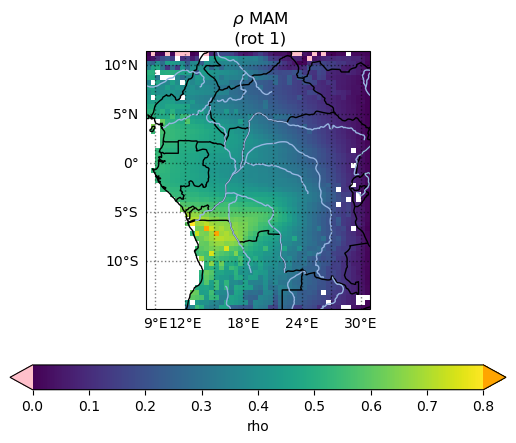

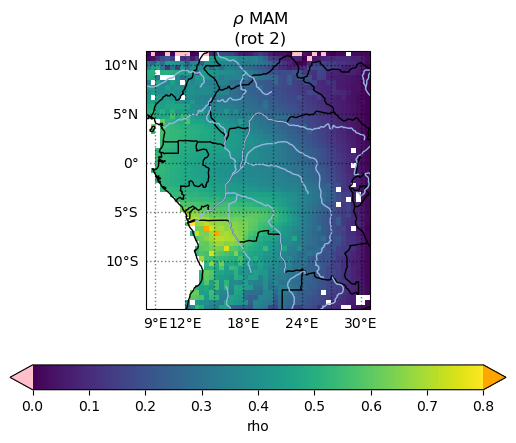

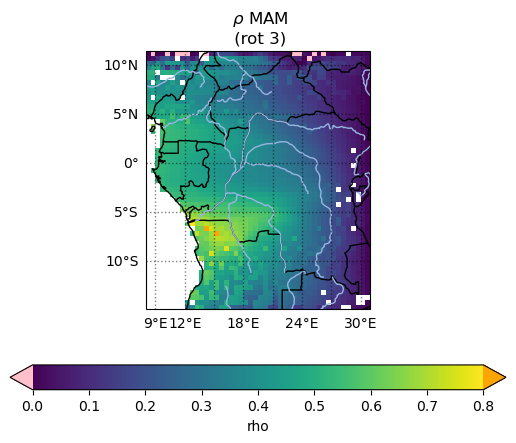

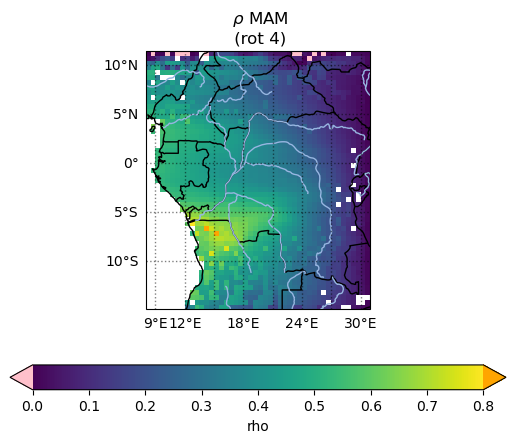

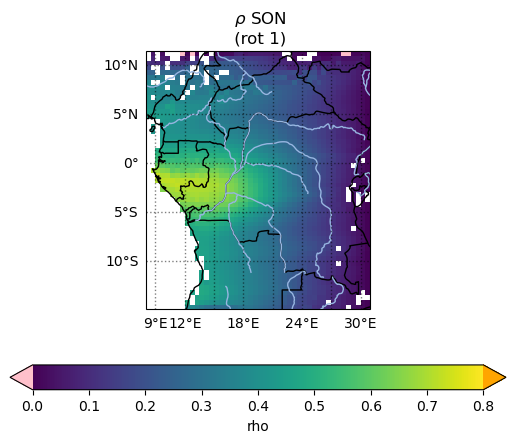

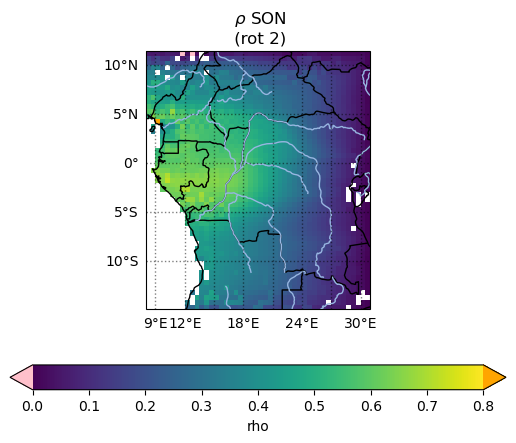

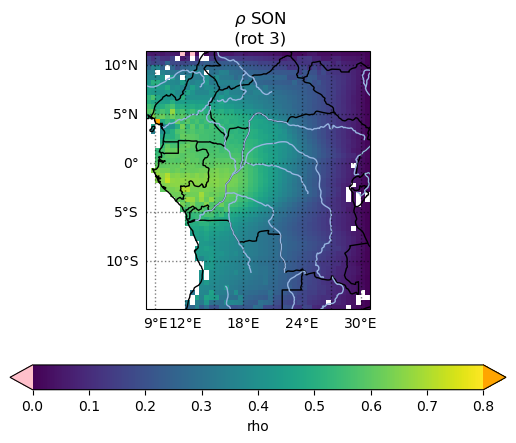

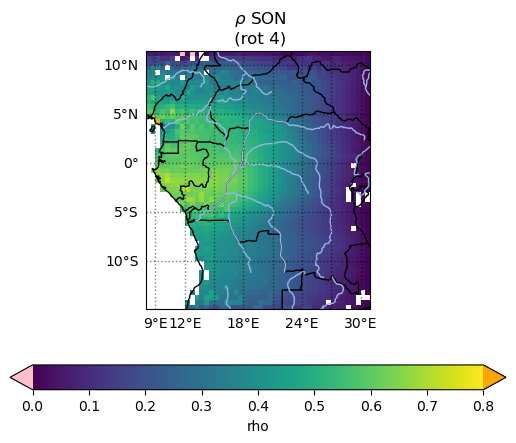

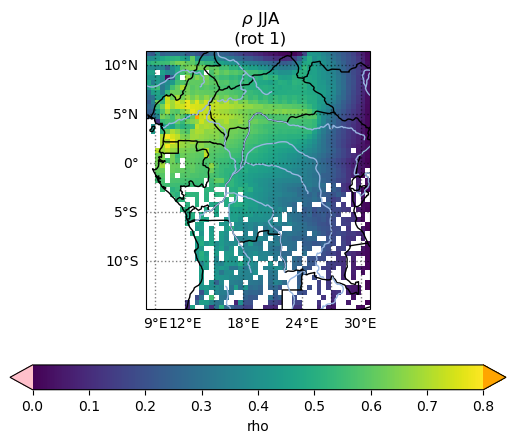

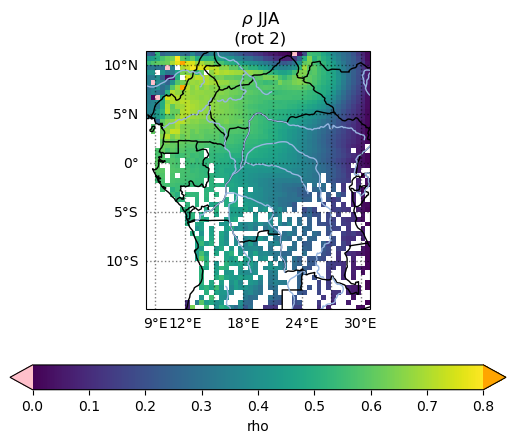

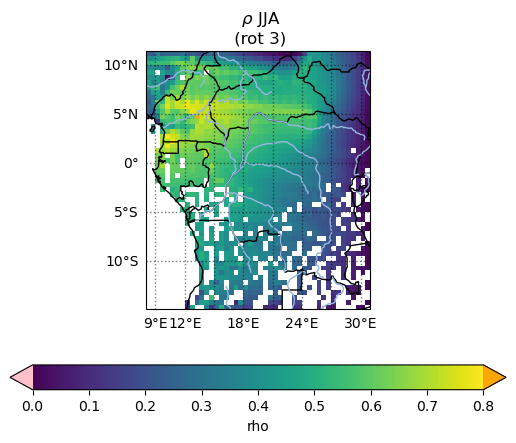

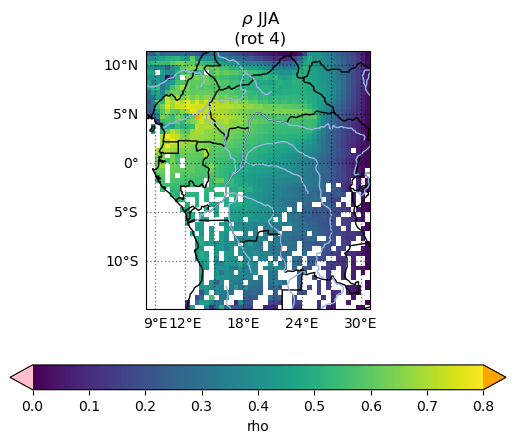

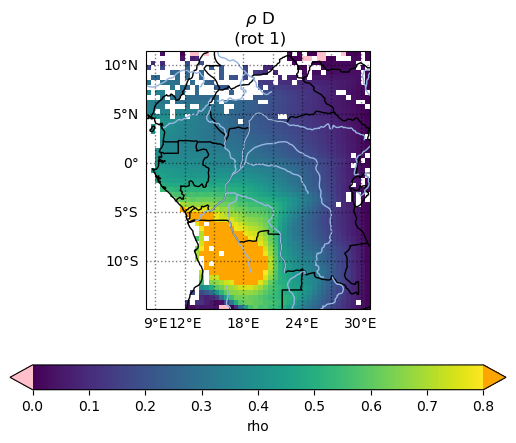

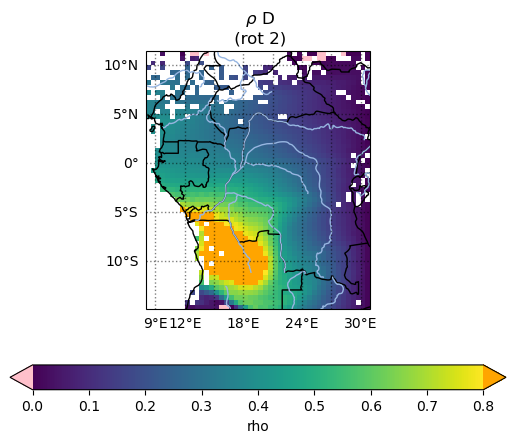

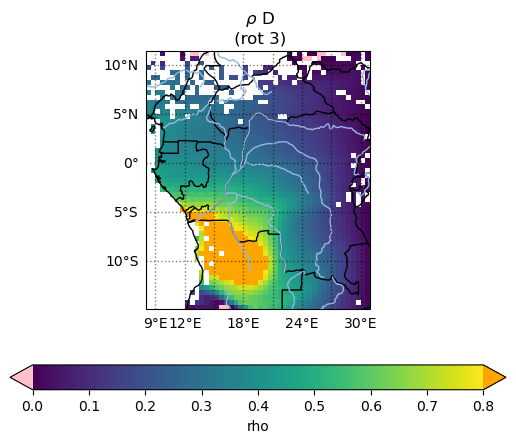

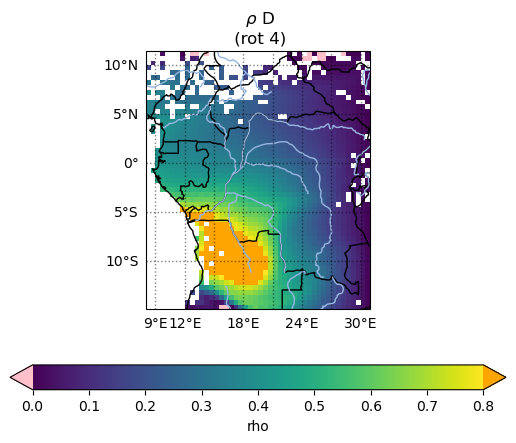

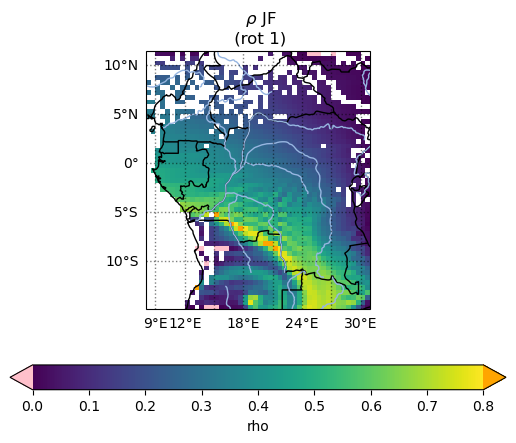

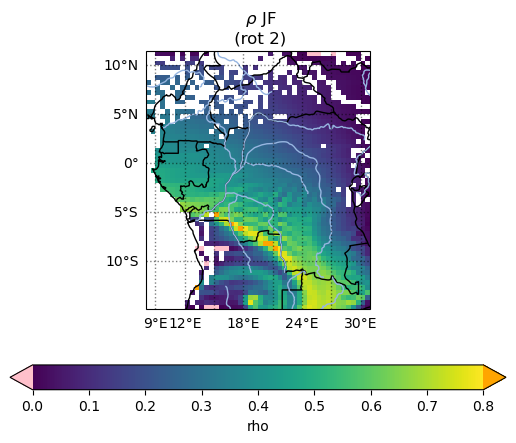

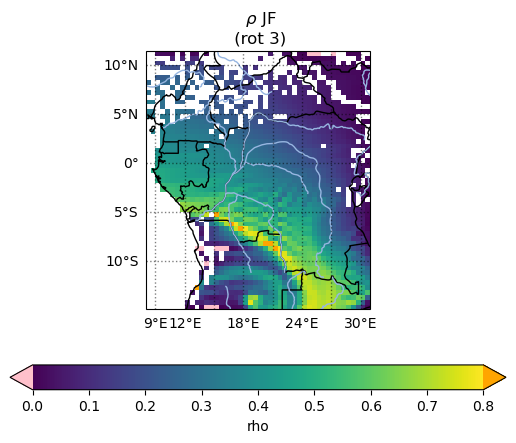

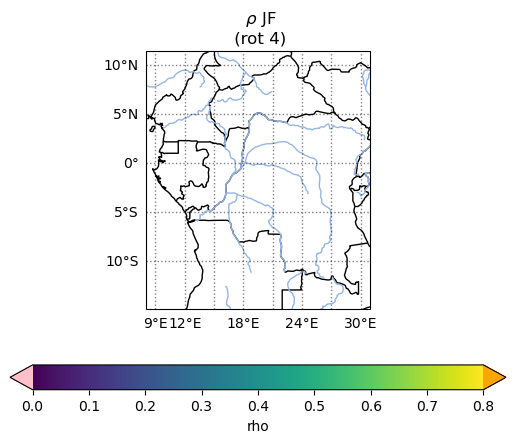

In [16]:
# Create seasonal arrays and plot these

R = rho_xarr_precip_filtered

seas={'MAM':[3,4,5],'SON':[9,10,11],'JJA':[6,7,8],'D':[12],'JF':[1,2]}
for S in seas:
    for r in np.arange(1,5):
        rho_plot = R['rho'][r-1,:,:,:] 
        seas_rho = rho_plot.sel(time=R.time.dt.month.isin(seas[S]))
        fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
        ax.coastlines()
        ax.add_feature(cartopy.feature.BORDERS)
        ax.add_feature(cartopy.feature.RIVERS)
        #ax.add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
        cmap=plt.cm.viridis
        cmap.set_extremes(over='orange',under='pink',bad='white')
        collection = seas_rho.mean("time").plot.pcolormesh(vmin=0.0,vmax=0.8,
                                                        #levels=13,
                                                        ax=ax,extend='both',cmap=cmap,
                                                        cbar_kwargs={"location":"bottom"} )
        #ax.set_extent([band[B][2],band[B][3],band[B][0],band[B][1]])
        ax.set_title(" $\\rho$"+" "+S+"\n (rot "+str(r)+")")
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
              linewidth=1, color='black', alpha=0.5, linestyle='dotted',zorder=100)
        gl.top_labels = False
        gl.right_labels = False
        #plt.savefig(datap+'nudged_max_'+str(max_iter)+'_tol_'+str(tol)+'_'+L_NAME+"_"+S_NAME+"_rho_"+S+"_"+str(YR)+"_region_rot"+str(r)+".png")
        plt.show()
        

rho_xarr.close()
    
    